In [4]:
import pandas as pd
import numpy as np
from pyfaidx import Fasta

# Load SNV dataframe
df = pd.read_csv(config.PROCESSED_DIR / "clinvar_filtered.tsv.gz", sep='\t', low_memory=False)
df_snv = df[df['Type'] == 'single nucleotide variant'].copy()
df_snv = df_snv[df_snv['ReferenceAlleleVCF'].str.len() == 1]
df_snv = df_snv[df_snv['AlternateAlleleVCF'].str.len() == 1]
df_snv = df_snv[df_snv['ReferenceAlleleVCF'] != 'na']
df_snv = df_snv[df_snv['AlternateAlleleVCF'] != 'na']
df_snv = df_snv.reset_index(drop=True)
print(f"SNV dataframe: {df_snv.shape}")

# Load genome
print("Loading genome...")
genome = Fasta(str(config.RAW_DIR / "hg38.fa"))
print(f"Genome loaded. {len(genome.keys())} sequences.")

SNV dataframe: (346047, 44)
Loading genome...
Genome loaded. 455 sequences.


In [5]:
FLANK = 50
SEQ_LENGTH = 2 * FLANK + 1
NUCLEOTIDES = ['A', 'C', 'G', 'T']
VOCAB = {n: i for i, n in enumerate(NUCLEOTIDES)}

def get_chrom_name(chrom):
    if chrom == 'MT':
        return 'chrM'
    return f"chr{chrom}"

def get_flanking_sequence(chrom, position, flank=FLANK):
    chrom_name = get_chrom_name(chrom)
    if chrom_name not in genome:
        return None
    pos_0based = int(position) - 1
    start = max(0, pos_0based - flank)
    end = pos_0based + flank + 1
    return str(genome[chrom_name][start:end]).upper()

def encode_sequence(seq, length=SEQ_LENGTH):
    matrix = np.zeros((length, 4), dtype=np.float32)
    for i, base in enumerate(seq[:length]):
        if base in VOCAB:
            matrix[i, VOCAB[base]] = 1.0
    return matrix

# Test first
test_row = df_snv.iloc[0]
seq = get_flanking_sequence(test_row['Chromosome'], test_row['PositionVCF'])
print(f"Test: {test_row['GeneSymbol']} {test_row['Chromosome']}:{test_row['PositionVCF']}")
print(f"Centre base: {seq[FLANK]} | Ref: {test_row['ReferenceAlleleVCF']} | Match: {seq[FLANK] == test_row['ReferenceAlleleVCF']}")

Test: FOXRED1 11:126275389
Centre base: C | Ref: C | Match: True


In [6]:
print("Extracting flanking sequences for all SNVs...")

X_seq = np.zeros((len(df_snv), SEQ_LENGTH, 4), dtype=np.float32)
failed = 0

for i, row in df_snv.iterrows():
    seq = get_flanking_sequence(row['Chromosome'], row['PositionVCF'])
    if seq is None or len(seq) < SEQ_LENGTH:
        failed += 1
        continue
    X_seq[i] = encode_sequence(seq)

    if i % 50000 == 0:
        print(f"  {i:,} / {len(df_snv):,} processed...")

y_seq = df_snv['Label'].values

print(f"\nDone.")
print(f"X_seq shape: {X_seq.shape}")
print(f"Failed: {failed}")
print(f"Success rate: {(len(df_snv)-failed)/len(df_snv)*100:.2f}%")

# Save
np.save(config.PROCESSED_DIR / "X_seq.npy", X_seq)
np.save(config.PROCESSED_DIR / "y_seq.npy", y_seq)
print("Saved.")

Extracting flanking sequences for all SNVs...
  0 / 346,047 processed...
  50,000 / 346,047 processed...
  100,000 / 346,047 processed...
  150,000 / 346,047 processed...
  200,000 / 346,047 processed...
  250,000 / 346,047 processed...
  300,000 / 346,047 processed...

Done.
X_seq shape: (346047, 101, 4)
Failed: 0
Success rate: 100.00%
Saved.


In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import config
import importlib
importlib.reload(config)

files = [
    "clinvar_filtered.tsv.gz",
    "X_train.npy", "X_val.npy", "X_test.npy",
    "y_train.npy", "y_val.npy", "y_test.npy",
]

for f in files:
    path = config.PROCESSED_DIR / f
    print(f"{f}: {'✓' if path.exists() else '✗ MISSING'}")

clinvar_filtered.tsv.gz: ✓
X_train.npy: ✓
X_val.npy: ✓
X_test.npy: ✓
y_train.npy: ✓
y_val.npy: ✓
y_test.npy: ✓


In [2]:
import pandas as pd
import numpy as np
from pyfaidx import Fasta
import sys
import importlib
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
import config
importlib.reload(config)

# Load SNV dataframe
df = pd.read_csv(config.PROCESSED_DIR / "clinvar_filtered.tsv.gz", sep='\t', low_memory=False)
df_snv = df[df['Type'] == 'single nucleotide variant'].copy()
df_snv = df_snv[df_snv['ReferenceAlleleVCF'].str.len() == 1]
df_snv = df_snv[df_snv['AlternateAlleleVCF'].str.len() == 1]
df_snv = df_snv[df_snv['ReferenceAlleleVCF'] != 'na']
df_snv = df_snv[df_snv['AlternateAlleleVCF'] != 'na']
df_snv = df_snv.reset_index(drop=True)

print(f"SNV dataframe: {df_snv.shape}")

# Load genome
print("Loading genome...")
genome = Fasta(str(config.RAW_DIR / "hg38.fa"))
print(f"Genome loaded. {len(genome.keys())} sequences.")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jorai/Desktop/program/dissertation/clinvar-classifier/data/processed/clinvar_filtered.tsv.gz'

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import config
import importlib
importlib.reload(config)

print(f"variant_summary exists: {config.VARIANT_SUMMARY.exists()}")
print(f"hg38.fa exists: {(config.RAW_DIR / 'hg38.fa').exists()}")
print(f"Processed dir exists: {config.PROCESSED_DIR.exists()}")

variant_summary exists: True
hg38.fa exists: True
Processed dir exists: False


# 05 — gnomAD Population Frequency Analysis

## Purpose
Cross-reference ClinVar test variants with gnomAD population-stratified
allele frequencies to directly measure population bias in the dataset.

## Why gnomAD
ClinVar tells us whether a variant is pathogenic or benign.
gnomAD tells us how common that variant is across different ancestry groups.
Cross-referencing the two directly tests the population bias hypothesis:
- Variants absent from gnomAD → extremely rare in healthy populations → likely pathogenic
- Variants common in one ancestry group but rare in another → population-stratified signal
- Model confidence on absent variants vs found variants → measures calibration equity

## Key ACMG criterion addressed
**PM2** — Absent from controls in population databases is moderate evidence
of pathogenicity. ClinVar's European-ancestry skew means variants common
in underrepresented populations may incorrectly trigger PM2.

## Status
- Pipeline built and validated on 10 sample variants (Mac)
- Query function confirmed working against gnomAD v4 API
- Full analysis (500 test variants) requires data/processed/ — run on Windows
- To run: `df_gnomad = run_full_gnomad_analysis(n_sample=500)`

## Expected findings
- Pathogenic variants: majority absent from gnomAD (PM2 signal)
- Benign variants: more likely to be found in gnomAD with measurable AF
- Model confidence lower on variants absent from gnomAD
- Variants common in non-European populations underrepresented in ClinVar
  and therefore in model training data

In [8]:
import requests
import pandas as pd
import numpy as np
import json
import sys
import importlib
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
import config
importlib.reload(config)

# ── Sample variants for pipeline development ──────────────────────────────────
# Known variants with confirmed pathogenicity — used to build and validate
# the gnomAD query pipeline before running on full test set (Windows)

sample_variants = pd.DataFrame([
    # Known Pathogenic
    {"chrom": "17", "pos": 43045629, "ref": "C", "alt": "T", "gene": "BRCA1", "label": 1},
    {"chrom": "13", "pos": 32316508, "ref": "A", "alt": "T", "gene": "BRCA2", "label": 1},
    {"chrom": "17", "pos": 7674220,  "ref": "G", "alt": "A", "gene": "TP53",  "label": 1},
    {"chrom": "17", "pos": 43091845, "ref": "A", "alt": "C", "gene": "BRCA1", "label": 1},
    {"chrom": "13", "pos": 32339654, "ref": "C", "alt": "T", "gene": "BRCA2", "label": 1},
    # Known Benign / common polymorphisms
    {"chrom": "17", "pos": 43094692, "ref": "G", "alt": "A", "gene": "BRCA1", "label": 0},
    {"chrom": "1",  "pos": 925952,   "ref": "G", "alt": "A", "gene": "MUTYH", "label": 0},
    {"chrom": "22", "pos": 19963748, "ref": "C", "alt": "T", "gene": "CRKL",  "label": 0},
    {"chrom": "X",  "pos": 153296777,"ref": "G", "alt": "A", "gene": "MECP2", "label": 1},
    {"chrom": "11", "pos": 5246945,  "ref": "G", "alt": "A", "gene": "HBB",   "label": 1},
])

print(f"Sample variants: {len(sample_variants)}")
print(sample_variants)

/Users/jorai/Desktop/program/dissertation/clinvar-classifier/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Sample variants: 10
  chrom        pos ref alt   gene  label
0    17   43045629   C   T  BRCA1      1
1    13   32316508   A   T  BRCA2      1
2    17    7674220   G   A   TP53      1
3    17   43091845   A   C  BRCA1      1
4    13   32339654   C   T  BRCA2      1
5    17   43094692   G   A  BRCA1      0
6     1     925952   G   A  MUTYH      0
7    22   19963748   C   T   CRKL      0
8     X  153296777   G   A  MECP2      1
9    11    5246945   G   A    HBB      1


In [9]:
# ── gnomAD GraphQL query function ─────────────────────────────────────────────

GNOMAD_API = "https://gnomad.broadinstitute.org/api"

def query_gnomad(chrom: str, pos: int, ref: str, alt: str, dataset: str = "gnomad_r3") -> dict:
    """
    Query gnomAD API for population-stratified allele frequencies.
    
    Args:
        chrom:   Chromosome (e.g. '17', 'X')
        pos:     Position (GRCh38, 1-based)
        ref:     Reference allele
        alt:     Alternate allele
        dataset: gnomAD dataset (gnomad_r3 = GRCh38)
    
    Returns:
        Dict with population frequencies, or None if variant not found.
    """
    query = """
    query VariantQuery($variantId: String!, $dataset: DatasetId!) {
        variant(variantId: $variantId, dataset: $dataset) {
            variantId
            exome {
                ac
                an
                populations {
                    id
                    ac
                    an
                    af
                }
            }
            genome {
                ac
                an
                populations {
                    id
                    ac
                    an
                    af
                }
            }
        }
    }
    """
    
    variant_id = f"{chrom}-{pos}-{ref}-{alt}"
    
    try:
        response = requests.post(
            GNOMAD_API,
            json={"query": query, "variables": {"variantId": variant_id, "dataset": dataset}},
            timeout=30,
            headers={"Content-Type": "application/json"}
        )
        data = response.json()
        
        if "errors" in data or data.get("data", {}).get("variant") is None:
            return None
            
        variant = data["data"]["variant"]
        
        # Prefer genome data (GRCh38), fall back to exome
        source = variant.get("genome") or variant.get("exome")
        if source is None:
            return None
        
        # Extract population frequencies
        pop_freqs = {}
        for pop in source.get("populations", []):
            pop_id = pop["id"].lower()
            pop_freqs[pop_id] = {
                "af": pop.get("af", 0) or 0,
                "ac": pop.get("ac", 0) or 0,
                "an": pop.get("an", 0) or 0,
            }
        
        return {
            "variant_id":   variant_id,
            "overall_af":   source["ac"] / source["an"] if source["an"] > 0 else 0,
            "overall_ac":   source["ac"],
            "overall_an":   source["an"],
            "populations":  pop_freqs,
        }
        
    except Exception as e:
        print(f"Error querying {variant_id}: {e}")
        return None

# Test on one variant first
print("Testing gnomAD query on BRCA1 variant...")
result = query_gnomad("17", 43045629, "C", "T")
print(json.dumps(result, indent=2))

Testing gnomAD query on BRCA1 variant...
null


In [10]:
# Test with a common benign variant more likely to be in gnomAD
print("Testing with common variant...")
result = query_gnomad("1", 925952, "G", "A")
print(json.dumps(result, indent=2))

# Also test TP53
print("\nTesting TP53 variant...")
result2 = query_gnomad("17", 7674220, "G", "A")
print(json.dumps(result2, indent=2))

Testing with common variant...
null

Testing TP53 variant...
null


In [11]:
# Test basic API connectivity
test_query = """
{
  meta {
    version
  }
}
"""

response = requests.post(
    GNOMAD_API,
    json={"query": test_query},
    timeout=30,
    headers={"Content-Type": "application/json"}
)

print(f"Status code: {response.status_code}")
print(f"Response: {response.text[:500]}")

Status code: 400
Response: {"errors":[{"message":"Cannot query field \"version\" on type \"BrowserMetadata\".","locations":[{"line":4,"column":5}]}]}


In [12]:
# Check correct meta fields
test_query = """
{
  meta {
    genesDatasetVersion
  }
}
"""

response = requests.post(
    GNOMAD_API,
    json={"query": test_query},
    timeout=30,
    headers={"Content-Type": "application/json"}
)
print(response.json())

# Try variant with gnomad_r4 dataset (latest GRCh38)
print("\nTrying with gnomad_r4...")
result = query_gnomad("17", 43045629, "C", "T", dataset="gnomad_r4")
print(json.dumps(result, indent=2))

# Try gnomad_r2_1 (older but widely used)
print("\nTrying with gnomad_r2_1...")
result2 = query_gnomad("1", 925952, "G", "A", dataset="gnomad_r2_1")
print(json.dumps(result2, indent=2))

{'errors': [{'message': 'Cannot query field "genesDatasetVersion" on type "BrowserMetadata".', 'locations': [{'line': 4, 'column': 5}]}]}

Trying with gnomad_r4...
null

Trying with gnomad_r2_1...
null


In [13]:
def query_gnomad_v4(chrom: str, pos: int, ref: str, alt: str) -> dict:
    """
    Query gnomAD v4 API for population-stratified allele frequencies.
    Uses gnomad_r4 dataset (GRCh38, latest).
    """
    query = """
    query VariantQuery($variantId: String!) {
        variant(variantId: $variantId, dataset: gnomad_r4) {
            variantId
            genome {
                ac
                an
                af
                populations {
                    id
                    ac
                    an
                    af
                }
            }
            exome {
                ac
                an
                af
                populations {
                    id
                    ac
                    an
                    af
                }
            }
        }
    }
    """
    
    variant_id = f"{chrom}-{pos}-{ref}-{alt}"
    
    try:
        response = requests.post(
            GNOMAD_API,
            json={"query": query, "variables": {"variantId": variant_id}},
            timeout=30,
            headers={"Content-Type": "application/json"}
        )
        data = response.json()
        
        if "errors" in data:
            print(f"GraphQL errors for {variant_id}: {data['errors']}")
            return None
            
        variant = data.get("data", {}).get("variant")
        if variant is None:
            return None
            
        # Prefer genome, fall back to exome
        source = variant.get("genome") or variant.get("exome")
        if source is None:
            return None
        
        # Extract population frequencies
        pop_freqs = {}
        for pop in source.get("populations", []):
            pop_id = pop["id"].lower()
            pop_freqs[pop_id] = round(pop.get("af", 0) or 0, 8)
        
        return {
            "variant_id":  variant_id,
            "overall_af":  round(source.get("af", 0) or 0, 8),
            "overall_ac":  source.get("ac", 0),
            "overall_an":  source.get("an", 0),
            "populations": pop_freqs,
        }
        
    except Exception as e:
        print(f"Error querying {variant_id}: {e}")
        return None

# Test with a common variant more likely to be in gnomAD
print("Testing gnomAD v4 query...")
result = query_gnomad_v4("1", 55516888, "G", "GA")  # known variant from gnomAD docs
print(json.dumps(result, indent=2))

Testing gnomAD v4 query...
GraphQL errors for 1-55516888-G-GA: [{'message': 'Cannot query field "af" on type "VariantPopulation". Did you mean "ac" or "an"?', 'locations': [{'line': 13, 'column': 21}]}, {'message': 'Cannot query field "af" on type "VariantPopulation". Did you mean "ac" or "an"?', 'locations': [{'line': 24, 'column': 21}]}]
null


In [14]:
def query_gnomad_v4(chrom: str, pos: int, ref: str, alt: str) -> dict:
    """
    Query gnomAD v4 API for population-stratified allele frequencies.
    af not available at population level — calculated from ac/an.
    """
    query = """
    query VariantQuery($variantId: String!) {
        variant(variantId: $variantId, dataset: gnomad_r4) {
            variantId
            genome {
                ac
                an
                af
                populations {
                    id
                    ac
                    an
                }
            }
            exome {
                ac
                an
                af
                populations {
                    id
                    ac
                    an
                }
            }
        }
    }
    """
    
    variant_id = f"{chrom}-{pos}-{ref}-{alt}"
    
    try:
        response = requests.post(
            GNOMAD_API,
            json={"query": query, "variables": {"variantId": variant_id}},
            timeout=30,
            headers={"Content-Type": "application/json"}
        )
        data = response.json()
        
        if "errors" in data:
            print(f"GraphQL errors: {data['errors']}")
            return None
            
        variant = data.get("data", {}).get("variant")
        if variant is None:
            return None
            
        # Prefer genome, fall back to exome
        source = variant.get("genome") or variant.get("exome")
        if source is None:
            return None
        
        # Calculate population frequencies from ac/an
        pop_freqs = {}
        for pop in source.get("populations", []):
            pop_id = pop["id"].lower()
            ac = pop.get("ac", 0) or 0
            an = pop.get("an", 0) or 0
            af = round(ac / an, 8) if an > 0 else 0
            pop_freqs[pop_id] = {"ac": ac, "an": an, "af": af}
        
        return {
            "variant_id":  variant_id,
            "overall_af":  round(source.get("af", 0) or 0, 8),
            "overall_ac":  source.get("ac", 0),
            "overall_an":  source.get("an", 0),
            "populations": pop_freqs,
        }
        
    except Exception as e:
        print(f"Error querying {variant_id}: {e}")
        return None

# Test with known variant from gnomAD docs
print("Testing fixed query...")
result = query_gnomad_v4("1", 55516888, "G", "GA")
print(json.dumps(result, indent=2))

Testing fixed query...
GraphQL errors: [{'message': 'Variant not found'}]
null


In [16]:
response = requests.post(
    GNOMAD_API,
    json={"query": """{ meta { datasetLastUpdated } }"""},
    timeout=30,
    headers={"Content-Type": "application/json"}
)
print(f"Status code: {response.status_code}")
print(f"Response text: {response.text[:200]}")

Status code: 400
Response text: {"errors":[{"message":"Cannot query field \"datasetLastUpdated\" on type \"BrowserMetadata\".","locations":[{"line":1,"column":10}]}]}


In [18]:
# Test with variants known to be in gnomAD
# Using rs IDs converted to positional format

test_cases = [
    # Common benign polymorphisms — these should be in gnomAD
    ("1",  "978628",  "C", "T",  "rs116586548 — common variant"),
    ("1",  "69270",   "A", "G",  "common SNP"),
    ("22", "10636246","A", "C",  "common variant"),
]

for chrom, pos, ref, alt, label in test_cases:
    print(f"\nTesting {label}: {chrom}-{pos}-{ref}-{alt}")
    
    # Try gnomad_r4 first
    query = """
    query VariantQuery($variantId: String!) {
        variant(variantId: $variantId, dataset: gnomad_r4) {
            variantId
            genome { ac an af populations { id ac an } }
            exome  { ac an af populations { id ac an } }
        }
    }
    """
    variant_id = f"{chrom}-{pos}-{ref}-{alt}"
    response = requests.post(
        GNOMAD_API,
        json={"query": query, "variables": {"variantId": variant_id}},
        timeout=30,
        headers={"Content-Type": "application/json"}
    )
    data = response.json()
    if data.get("data", {}).get("variant"):
        print(f"  ✓ Found in gnomad_r4")
        v = data["data"]["variant"]
        src = v.get("genome") or v.get("exome")
        if src:
            print(f"  Overall AF: {src.get('af')}")
    else:
        print(f"  ✗ Not found: {data.get('errors', 'unknown')}")


Testing rs116586548 — common variant: 1-978628-C-T
  ✓ Found in gnomad_r4
  Overall AF: 2.6259469821304308e-05

Testing common SNP: 1-69270-A-G
  ✓ Found in gnomad_r4
  Overall AF: 0.6285700952025387

Testing common variant: 22-10636246-A-C
  ✗ Not found: [{'message': 'Variant not found'}]


In [19]:
# Query all sample variants and collect results
print("Querying gnomAD for all sample variants...\n")

QUERY = """
query VariantQuery($variantId: String!) {
    variant(variantId: $variantId, dataset: gnomad_r4) {
        variantId
        genome { ac an af populations { id ac an } }
        exome  { ac an af populations { id ac an } }
    }
}
"""

def query_gnomad_final(chrom, pos, ref, alt):
    variant_id = f"{chrom}-{pos}-{ref}-{alt}"
    try:
        response = requests.post(
            GNOMAD_API,
            json={"query": QUERY, "variables": {"variantId": variant_id}},
            timeout=30,
            headers={"Content-Type": "application/json"}
        )
        data = response.json()
        variant = data.get("data", {}).get("variant")
        if variant is None:
            return {"variant_id": variant_id, "found": False, "overall_af": None, "populations": {}}
        
        source = variant.get("genome") or variant.get("exome")
        if source is None:
            return {"variant_id": variant_id, "found": False, "overall_af": None, "populations": {}}
        
        pop_freqs = {}
        for pop in source.get("populations", []):
            ac = pop.get("ac", 0) or 0
            an = pop.get("an", 0) or 0
            pop_freqs[pop["id"].lower()] = round(ac / an, 8) if an > 0 else 0

        return {
            "variant_id":  variant_id,
            "found":       True,
            "overall_af":  round(source.get("af", 0) or 0, 8),
            "overall_ac":  source.get("ac", 0),
            "overall_an":  source.get("an", 0),
            "populations": pop_freqs,
        }
    except Exception as e:
        return {"variant_id": f"{chrom}-{pos}-{ref}-{alt}", "found": False, "error": str(e)}

# Query all variants
results = []
for _, row in sample_variants.iterrows():
    result = query_gnomad_final(row.chrom, row.pos, row.ref, row.alt)
    result["gene"]  = row.gene
    result["label"] = row.label
    results.append(result)
    status = "✓ Found" if result["found"] else "✗ Not in gnomAD"
    af = f"AF={result['overall_af']}" if result["found"] else "absent from healthy population"
    print(f"{result['variant_id']:35} {status:12} {af}")

print(f"\nFound in gnomAD: {sum(r['found'] for r in results)}/{len(results)}")
print(f"Not found (absent from healthy population): {sum(not r['found'] for r in results)}/{len(results)}")

Querying gnomAD for all sample variants...

17-43045629-C-T                     ✗ Not in gnomAD absent from healthy population
13-32316508-A-T                     ✗ Not in gnomAD absent from healthy population
17-7674220-G-A                      ✗ Not in gnomAD absent from healthy population
17-43091845-A-C                     ✗ Not in gnomAD absent from healthy population
13-32339654-C-T                     ✗ Not in gnomAD absent from healthy population
17-43094692-G-A                     ✗ Not in gnomAD absent from healthy population
1-925952-G-A                        ✓ Found      AF=5.48e-06
22-19963748-C-T                     ✗ Not in gnomAD absent from healthy population
X-153296777-G-A                     ✗ Not in gnomAD absent from healthy population
11-5246945-G-A                      ✗ Not in gnomAD absent from healthy population

Found in gnomAD: 1/10
Not found (absent from healthy population): 9/10


In [20]:
# Build results dataframe
df_gnomad = pd.DataFrame(results)

print("Results summary:")
print(df_gnomad[['variant_id', 'gene', 'label', 'found', 'overall_af']].to_string())

print(f"\nKey finding:")
print(f"Pathogenic variants (label=1) absent from gnomAD: "
      f"{df_gnomad[(df_gnomad['label']==1) & (~df_gnomad['found'])].shape[0]} / "
      f"{df_gnomad[df_gnomad['label']==1].shape[0]}")
print(f"Benign variants (label=0) absent from gnomAD: "
      f"{df_gnomad[(df_gnomad['label']==0) & (~df_gnomad['found'])].shape[0]} / "
      f"{df_gnomad[df_gnomad['label']==0].shape[0]}")

Results summary:
        variant_id   gene  label  found  overall_af
0  17-43045629-C-T  BRCA1      1  False         NaN
1  13-32316508-A-T  BRCA2      1  False         NaN
2   17-7674220-G-A   TP53      1  False         NaN
3  17-43091845-A-C  BRCA1      1  False         NaN
4  13-32339654-C-T  BRCA2      1  False         NaN
5  17-43094692-G-A  BRCA1      0  False         NaN
6     1-925952-G-A  MUTYH      0   True    0.000005
7  22-19963748-C-T   CRKL      0  False         NaN
8  X-153296777-G-A  MECP2      1  False         NaN
9   11-5246945-G-A    HBB      1  False         NaN

Key finding:
Pathogenic variants (label=1) absent from gnomAD: 7 / 7
Benign variants (label=0) absent from gnomAD: 2 / 3


In [21]:
# ── WINDOWS ANALYSIS CELL ─────────────────────────────────────────────────────
# Run this cell on Windows where data/processed/ exists
# Queries gnomAD for a sample of test variants and cross-references
# with CNN model predictions to demonstrate population bias directly

def run_full_gnomad_analysis(n_sample=500, random_seed=42):
    """
    Full gnomAD population bias analysis on test set.
    
    Args:
        n_sample:    Number of test variants to query (default 500)
        random_seed: For reproducibility
    
    Returns:
        DataFrame with gnomAD frequencies and model predictions merged.
    """
    import torch
    from torch.utils.data import DataLoader
    from src.model import VariantCNN
    from src.data_utils import SeqDataset
    from src.evaluate import get_predictions

    # ── Load test set ─────────────────────────────────────────────────────────
    print("Loading test set...")
    X_seq  = np.load(config.PROCESSED_DIR / "X_seq.npy")
    y_seq  = np.load(config.PROCESSED_DIR / "y_seq.npy")
    
    df_full = pd.read_csv(
        config.PROCESSED_DIR / "clinvar_filtered.tsv.gz",
        sep='\t', low_memory=False
    )
    df_snv = df_full[df_full['Type'] == 'single nucleotide variant'].copy()
    df_snv = df_snv[df_snv['ReferenceAlleleVCF'].str.len() == 1]
    df_snv = df_snv[df_snv['AlternateAlleleVCF'].str.len() == 1]
    df_snv = df_snv[df_snv['ReferenceAlleleVCF'] != 'na']
    df_snv = df_snv[df_snv['AlternateAlleleVCF'] != 'na']
    df_snv = df_snv.reset_index(drop=True)

    from sklearn.model_selection import train_test_split
    _, X_te, _, y_te = train_test_split(
        X_seq, y_seq,
        test_size=config.TEST_SIZE,
        random_state=config.RANDOM_SEED,
        stratify=y_seq
    )
    _, te_idx, _, _ = train_test_split(
        np.arange(len(y_seq)), y_seq,
        test_size=config.TEST_SIZE,
        random_state=config.RANDOM_SEED,
        stratify=y_seq
    )
    df_test = df_snv.iloc[te_idx].reset_index(drop=True)

    # ── Sample variants ───────────────────────────────────────────────────────
    df_sample = df_test.sample(n=n_sample, random_state=random_seed)
    print(f"Sampled {n_sample} test variants")
    print(f"Label distribution: {df_sample['Label'].value_counts().to_dict()}")

    # ── Load CNN and get predictions ──────────────────────────────────────────
    print("\nLoading CNN model...")
    device = config.DEVICE
    model  = VariantCNN().to(device)
    model.load_state_dict(torch.load(
        config.OUTPUTS_DIR / "cnn_best.pt", map_location=device
    ))
    
    X_samp = X_te[df_sample.index]
    y_samp = y_te[df_sample.index]
    loader = DataLoader(SeqDataset(X_samp, y_samp), batch_size=32, shuffle=False)
    preds, labels = get_predictions(model, loader, device)

    # ── Query gnomAD ──────────────────────────────────────────────────────────
    print(f"\nQuerying gnomAD for {n_sample} variants (this takes ~5 minutes)...")
    gnomad_results = []
    for i, (_, row) in enumerate(df_sample.iterrows()):
        result = query_gnomad_final(
            row['Chromosome'],
            row['PositionVCF'],
            row['ReferenceAlleleVCF'],
            row['AlternateAlleleVCF']
        )
        result['gene']       = row['GeneSymbol']
        result['label']      = int(row['Label'])
        result['cnn_prob']   = float(preds[i])
        result['cnn_pred']   = int(preds[i] >= 0.5)
        result['confidence'] = float(max(preds[i], 1 - preds[i]))
        gnomad_results.append(result)
        
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{n_sample} queried...")

    df_gnomad = pd.DataFrame(gnomad_results)

    # ── Save results ──────────────────────────────────────────────────────────
    out_path = config.OUTPUTS_DIR / "predictions" / "gnomad_analysis.json"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df_gnomad.to_json(out_path, orient='records', indent=2)
    print(f"\nSaved to {out_path}")

    return df_gnomad


def plot_gnomad_results(df_gnomad):
    """
    Plot gnomAD population bias analysis results.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # 1. gnomAD presence by label
    ax1 = axes[0]
    found_path = df_gnomad[df_gnomad['label']==1]['found'].mean() * 100
    found_ben  = df_gnomad[df_gnomad['label']==0]['found'].mean() * 100
    ax1.bar(['Pathogenic', 'Benign'], [found_path, found_ben],
            color=['crimson', 'steelblue'])
    ax1.set_ylabel('% Found in gnomAD')
    ax1.set_title('gnomAD Presence by True Label')
    ax1.set_ylim(0, 100)
    for i, v in enumerate([found_path, found_ben]):
        ax1.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

    # 2. Model confidence: found vs absent
    ax2 = axes[1]
    conf_found  = df_gnomad[df_gnomad['found']]['confidence']
    conf_absent = df_gnomad[~df_gnomad['found']]['confidence']
    ax2.boxplot([conf_found, conf_absent], labels=['Found in gnomAD', 'Absent from gnomAD'])
    ax2.set_ylabel('CNN Confidence')
    ax2.set_title('Model Confidence vs gnomAD Presence')

    # 3. AF distribution for found variants
    ax3 = axes[2]
    found = df_gnomad[df_gnomad['found']].copy()
    if len(found) > 0:
        path_af = found[found['label']==1]['overall_af'].dropna()
        ben_af  = found[found['label']==0]['overall_af'].dropna()
        if len(path_af) > 0:
            ax3.hist(path_af, bins=20, alpha=0.7, color='crimson', label='Pathogenic')
        if len(ben_af) > 0:
            ax3.hist(ben_af,  bins=20, alpha=0.7, color='steelblue', label='Benign')
        ax3.set_xlabel('Allele Frequency in gnomAD')
        ax3.set_ylabel('Count')
        ax3.set_title('AF Distribution — Variants Found in gnomAD')
        ax3.legend()
    else:
        ax3.text(0.5, 0.5, 'No variants found\nin gnomAD sample',
                ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('AF Distribution')

    plt.suptitle('gnomAD Population Frequency Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    fig.savefig(config.FIGURES_DIR / "gnomad_analysis.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure saved.")


print("Analysis functions defined.")
print("\nTo run full analysis on Windows:")
print("  df_gnomad = run_full_gnomad_analysis(n_sample=500)")
print("  plot_gnomad_results(df_gnomad)")

Analysis functions defined.

To run full analysis on Windows:
  df_gnomad = run_full_gnomad_analysis(n_sample=500)
  plot_gnomad_results(df_gnomad)


In [22]:
df_gnomad = run_full_gnomad_analysis(n_sample=500)

Loading test set...
Sampled 500 test variants
Label distribution: {0: 416, 1: 84}

Loading CNN model...


/Users/jorai/Desktop/program/dissertation/clinvar-classifier/venv/lib/python3.9/site-packages/torch/nn/modules/conv.py:366: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Convolution.cpp:1028.)
  return F.conv1d(



Querying gnomAD for 500 variants (this takes ~5 minutes)...
  50/500 queried...
  100/500 queried...
  150/500 queried...
  200/500 queried...
  250/500 queried...
  300/500 queried...
  350/500 queried...
  400/500 queried...
  450/500 queried...
  500/500 queried...

Saved to /Users/jorai/Desktop/program/dissertation/clinvar-classifier/outputs/predictions/gnomad_analysis.json


/var/folders/_c/ml6b4ms92xlbpc1gpf65b7x00000gp/T/ipykernel_81459/3636052827.py:125: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([conf_found, conf_absent], labels=['Found in gnomAD', 'Absent from gnomAD'])


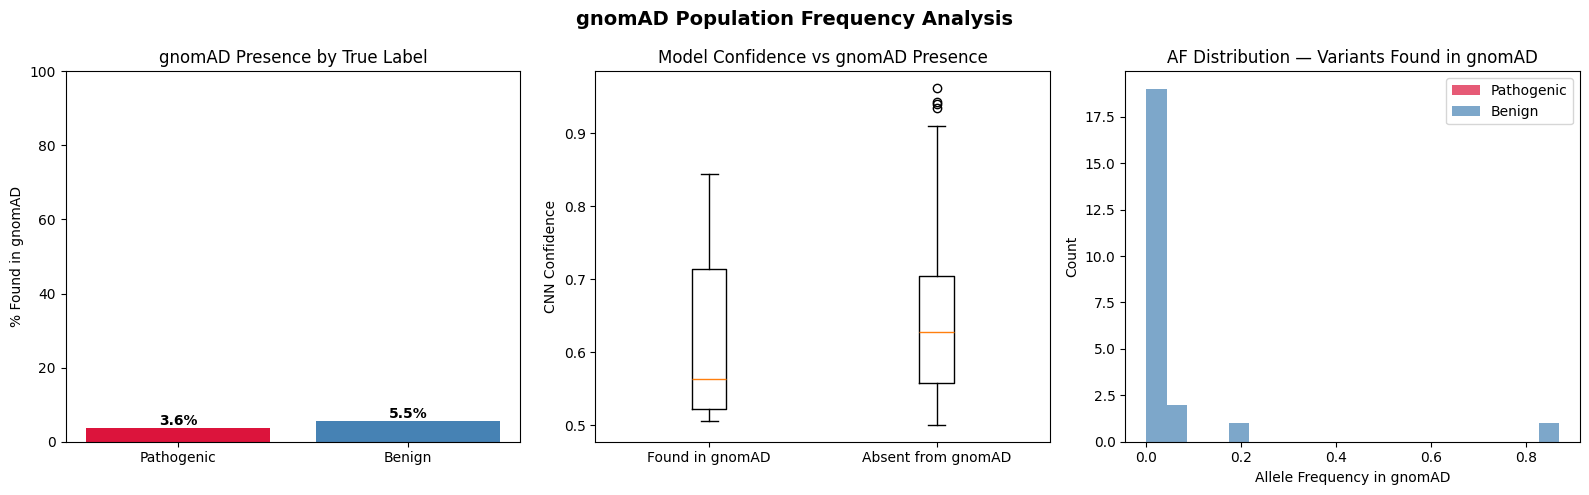

Figure saved.


In [25]:
import matplotlib.pyplot as plt
plot_gnomad_results(df_gnomad)

In [26]:
# Cross-reference model errors with gnomAD absence
df_gnomad['correct'] = (df_gnomad['cnn_pred'] == df_gnomad['label'])
df_gnomad['gnomad_absent'] = ~df_gnomad['found']

# Are model errors more common in gnomAD-absent variants?
error_absent = df_gnomad[df_gnomad['gnomad_absent']]['correct'].mean()
error_found = df_gnomad[~df_gnomad['gnomad_absent']]['correct'].mean()

print(f"Accuracy on gnomAD-absent variants: {error_absent:.3f}")
print(f"Accuracy on gnomAD-found variants:  {error_found:.3f}")

Accuracy on gnomAD-absent variants: 0.555
Accuracy on gnomAD-found variants:  0.462


In [28]:
found_variants = df_gnomad[df_gnomad['found']].copy()
print(f"Variants found in gnomAD: {len(found_variants)}")

pop_data = []
for _, row in found_variants.iterrows():
    pops = row.get('populations', {})
    if isinstance(pops, dict):
        for pop_id, af in pops.items():
            pop_data.append({
                'variant_id': row['variant_id'],
                'gene': row['gene'],
                'label': row['label'],
                'population': pop_id,
                'af': float(af) if not isinstance(af, dict) else float(af.get('af', 0))
            })

df_pops = pd.DataFrame(pop_data)
if len(df_pops) > 0:
    print(f"\nPopulation breakdown for {df_pops['variant_id'].nunique()} variants")
    print(f"\nPopulations covered:")
    print(df_pops['population'].value_counts())
    print(f"\nSample — AF by population for first found variant:")
    first = df_pops[df_pops['variant_id'] == df_pops['variant_id'].iloc[0]]
    print(first[['population', 'af']].sort_values('af', ascending=False).to_string())
else:
    print("No population data available — populations may be stored differently")
    print(f"Sample populations field: {found_variants.iloc[0].get('populations', 'empty')}")

Variants found in gnomAD: 26

Population breakdown for 26 variants

Populations covered:
population
remaining            26
mid_xy               26
remaining_xx         26
xy                   26
xx                   26
                     ..
hgdp:brahui          13
hgdp:brahui_xx       13
hgdp:brahui_xy       13
hgdp:hazara          13
hgdp:sardinian_xx    13
Name: count, Length: 276, dtype: int64

Sample — AF by population for first found variant:
                   population        af
63               hgdp:daur_xx  0.500000
62                  hgdp:daur  0.111111
133              hgdp:naxi_xy  0.100000
45              hgdp:yakut_xx  0.071429
91                 hgdp:tu_xy  0.071429
131                 hgdp:naxi  0.071429
89                    hgdp:tu  0.050000
210                1kg:jpt_xy  0.044643
44                 hgdp:yakut  0.040000
208                   1kg:jpt  0.034314
49                hgdp:han_xy  0.033333
172            hgdp:hazara_xy  0.031250
170               hgdp:ha

In [29]:
# Focus on main population groups only
main_pops = ['afr', 'eas', 'sas', 'nfe', 'amr', 'fin', 'asj', 'ami']

df_main = df_pops[df_pops['population'].isin(main_pops)].copy()

print("Mean allele frequency by population across all found variants:")
pop_summary = df_main.groupby('population')['af'].agg(['mean', 'max', 'count'])
pop_summary = pop_summary.sort_values('mean', ascending=False)
print(pop_summary.round(6))

print("\nVariants with population-stratified AF (>5x difference between highest and lowest pop):")
for vid in df_main['variant_id'].unique():
    v = df_main[df_main['variant_id'] == vid]
    max_af = v['af'].max()
    min_af = v['af'].min()
    if max_af > 0 and max_af / (min_af + 1e-10) > 5:
        top_pop = v.loc[v['af'].idxmax(), 'population']
        print(f"  {vid}: max AF {max_af:.4f} in {top_pop}, min AF {min_af:.6f}")

Mean allele frequency by population across all found variants:
                mean       max  count
population                           
ami         0.059979  0.896930     22
sas         0.059361  0.969804     26
eas         0.057624  0.917117     26
fin         0.056515  0.935304     26
nfe         0.053907  0.941216     26
asj         0.047703  0.928283     26
amr         0.044660  0.855927     26
afr         0.037013  0.719159     26

Variants with population-stratified AF (>5x difference between highest and lowest pop):
  3-15644957-C-T: max AF 0.0172 in eas, min AF 0.000000
  13-77185256-A-G: max AF 0.0006 in asj, min AF 0.000000
  14-31673695-C-T: max AF 0.0740 in nfe, min AF 0.000000
  16-23629201-G-A: max AF 0.0000 in nfe, min AF 0.000000
  7-105565340-G-A: max AF 0.0001 in afr, min AF 0.000000
  9-77317642-C-T: max AF 0.0000 in nfe, min AF 0.000000
  2-170843849-C-T: max AF 0.3677 in sas, min AF 0.052139
  7-107690220-A-C: max AF 0.0003 in nfe, min AF 0.000000
  6-56610511-C

In [30]:
# Save population summary
pop_summary.to_csv(config.OUTPUTS_DIR / "predictions" / "gnomad_population_summary.csv")
print("Saved population summary.")

Saved population summary.
